In [1]:
!pip install myplotlib

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 3.0 MB 4.9 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
    Preparing wheel metadata ... done
  Created wheel for myplotlib: filename=myplotlib-1.0.1-py3-none-any.whl size=3034007 sha256=708eb2576ca1379f7fa62953486471768ba86293fd6aac0664faaa10da819175
  Stored in directory: /root/.cache/pip/wheels/05/e5/31/37756dd6222b23689059bac128f6d375509d23bc33da95198c
Successfully built myplotlib


In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.io import wavfile
from scipy import signal

import myplotlib.plots as myplt
import myplotlib
myplotlib.load('mono')

data = np.arange(100, 0, -1).reshape(10, 10)

def addCbar(fig, ax, im, cbar='5%', pad=0.05):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

In [3]:
import scipy.io.wavfile as wav
from numpy.lib import stride_tricks

""" short time fourier transform of audio signal """
def stft(sig, frameSize, overlapFac=0.5, window=np.hanning):
    win = window(frameSize)
    hopSize = int(frameSize - np.floor(overlapFac * frameSize))

    # zeros at beginning (thus center of 1st window should be for sample nr. 0)   
    samples = np.append(np.zeros(int(np.floor(frameSize/2.0))), sig)    
    # cols for windowing
    cols = np.ceil( (len(samples) - frameSize) / float(hopSize)) + 1
    # zeros at end (thus samples can be fully covered by frames)
    samples = np.append(samples, np.zeros(frameSize))

    frames = stride_tricks.as_strided(samples, shape=(int(cols), frameSize), strides=(samples.strides[0]*hopSize, samples.strides[0])).copy()
    frames *= win

    return np.fft.rfft(frames)    

""" scale frequency axis logarithmically """    
def logscale_spec(spec, sr=44100, factor=20.):
    timebins, freqbins = np.shape(spec)

    scale = np.linspace(0, 1, freqbins) ** factor
    scale *= (freqbins-1)/max(scale)
    scale = np.unique(np.round(scale))

    # create spectrogram with new freq bins
    newspec = np.complex128(np.zeros([timebins, len(scale)]))
    for i in range(0, len(scale)):        
        if i == len(scale)-1:
            newspec[:,i] = np.sum(spec[:,int(scale[i]):], axis=1)
        else:        
            newspec[:,i] = np.sum(spec[:,int(scale[i]):int(scale[i+1])], axis=1)

    # list center freq of bins
    allfreqs = np.abs(np.fft.fftfreq(freqbins*2, 1./sr)[:freqbins+1])
    freqs = []
    for i in range(0, len(scale)):
        if i == len(scale)-1:
            freqs += [np.mean(allfreqs[int(scale[i]):])]
        else:
            freqs += [np.mean(allfreqs[int(scale[i]):int(scale[i+1])])]

    return newspec, freqs

In [151]:
# samplerate, samples = wavfile.read('plane-1.wav')
# props = dict(vmin=-80, vmax=-35, NFFT=2**12, noverlap=2**8)
# lims = dict(ylim=(0, 3000))

# samplerate, samples = wavfile.read('plane-2.wav')
# props = dict(vmin=90, vmax=140, NFFT=2**10, noverlap=2**4)
# lims = dict(ylim=(0, 8000))

# samplerate, samples = wavfile.read('plane-3.wav')
# props = dict(vmin=80, vmax=145, NFFT=2**13, noverlap=2**8)
# lims = dict(ylim=(0, 8000))
# samples = samples[:, 0]

samplerate, samples = wavfile.read('airliner-1.wav')
props = dict(vmin=0, vmax=50, NFFT=2**12, noverlap=2**8)
lims = dict(ylim=(0, 2000))
samples = samples[:, 0]

# samplerate, samples = wavfile.read('heli-1.wav')
# props = dict(vmin=-20, vmax=30, NFFT=2**11, noverlap=2**8)
# lims = dict(ylim=(0, 8000))
# samples = samples[:, 0]

samples.shape

<ipython-input-151-9e560d68ebc4>:14: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, samples = wavfile.read('airliner-1.wav')


(4664659,)

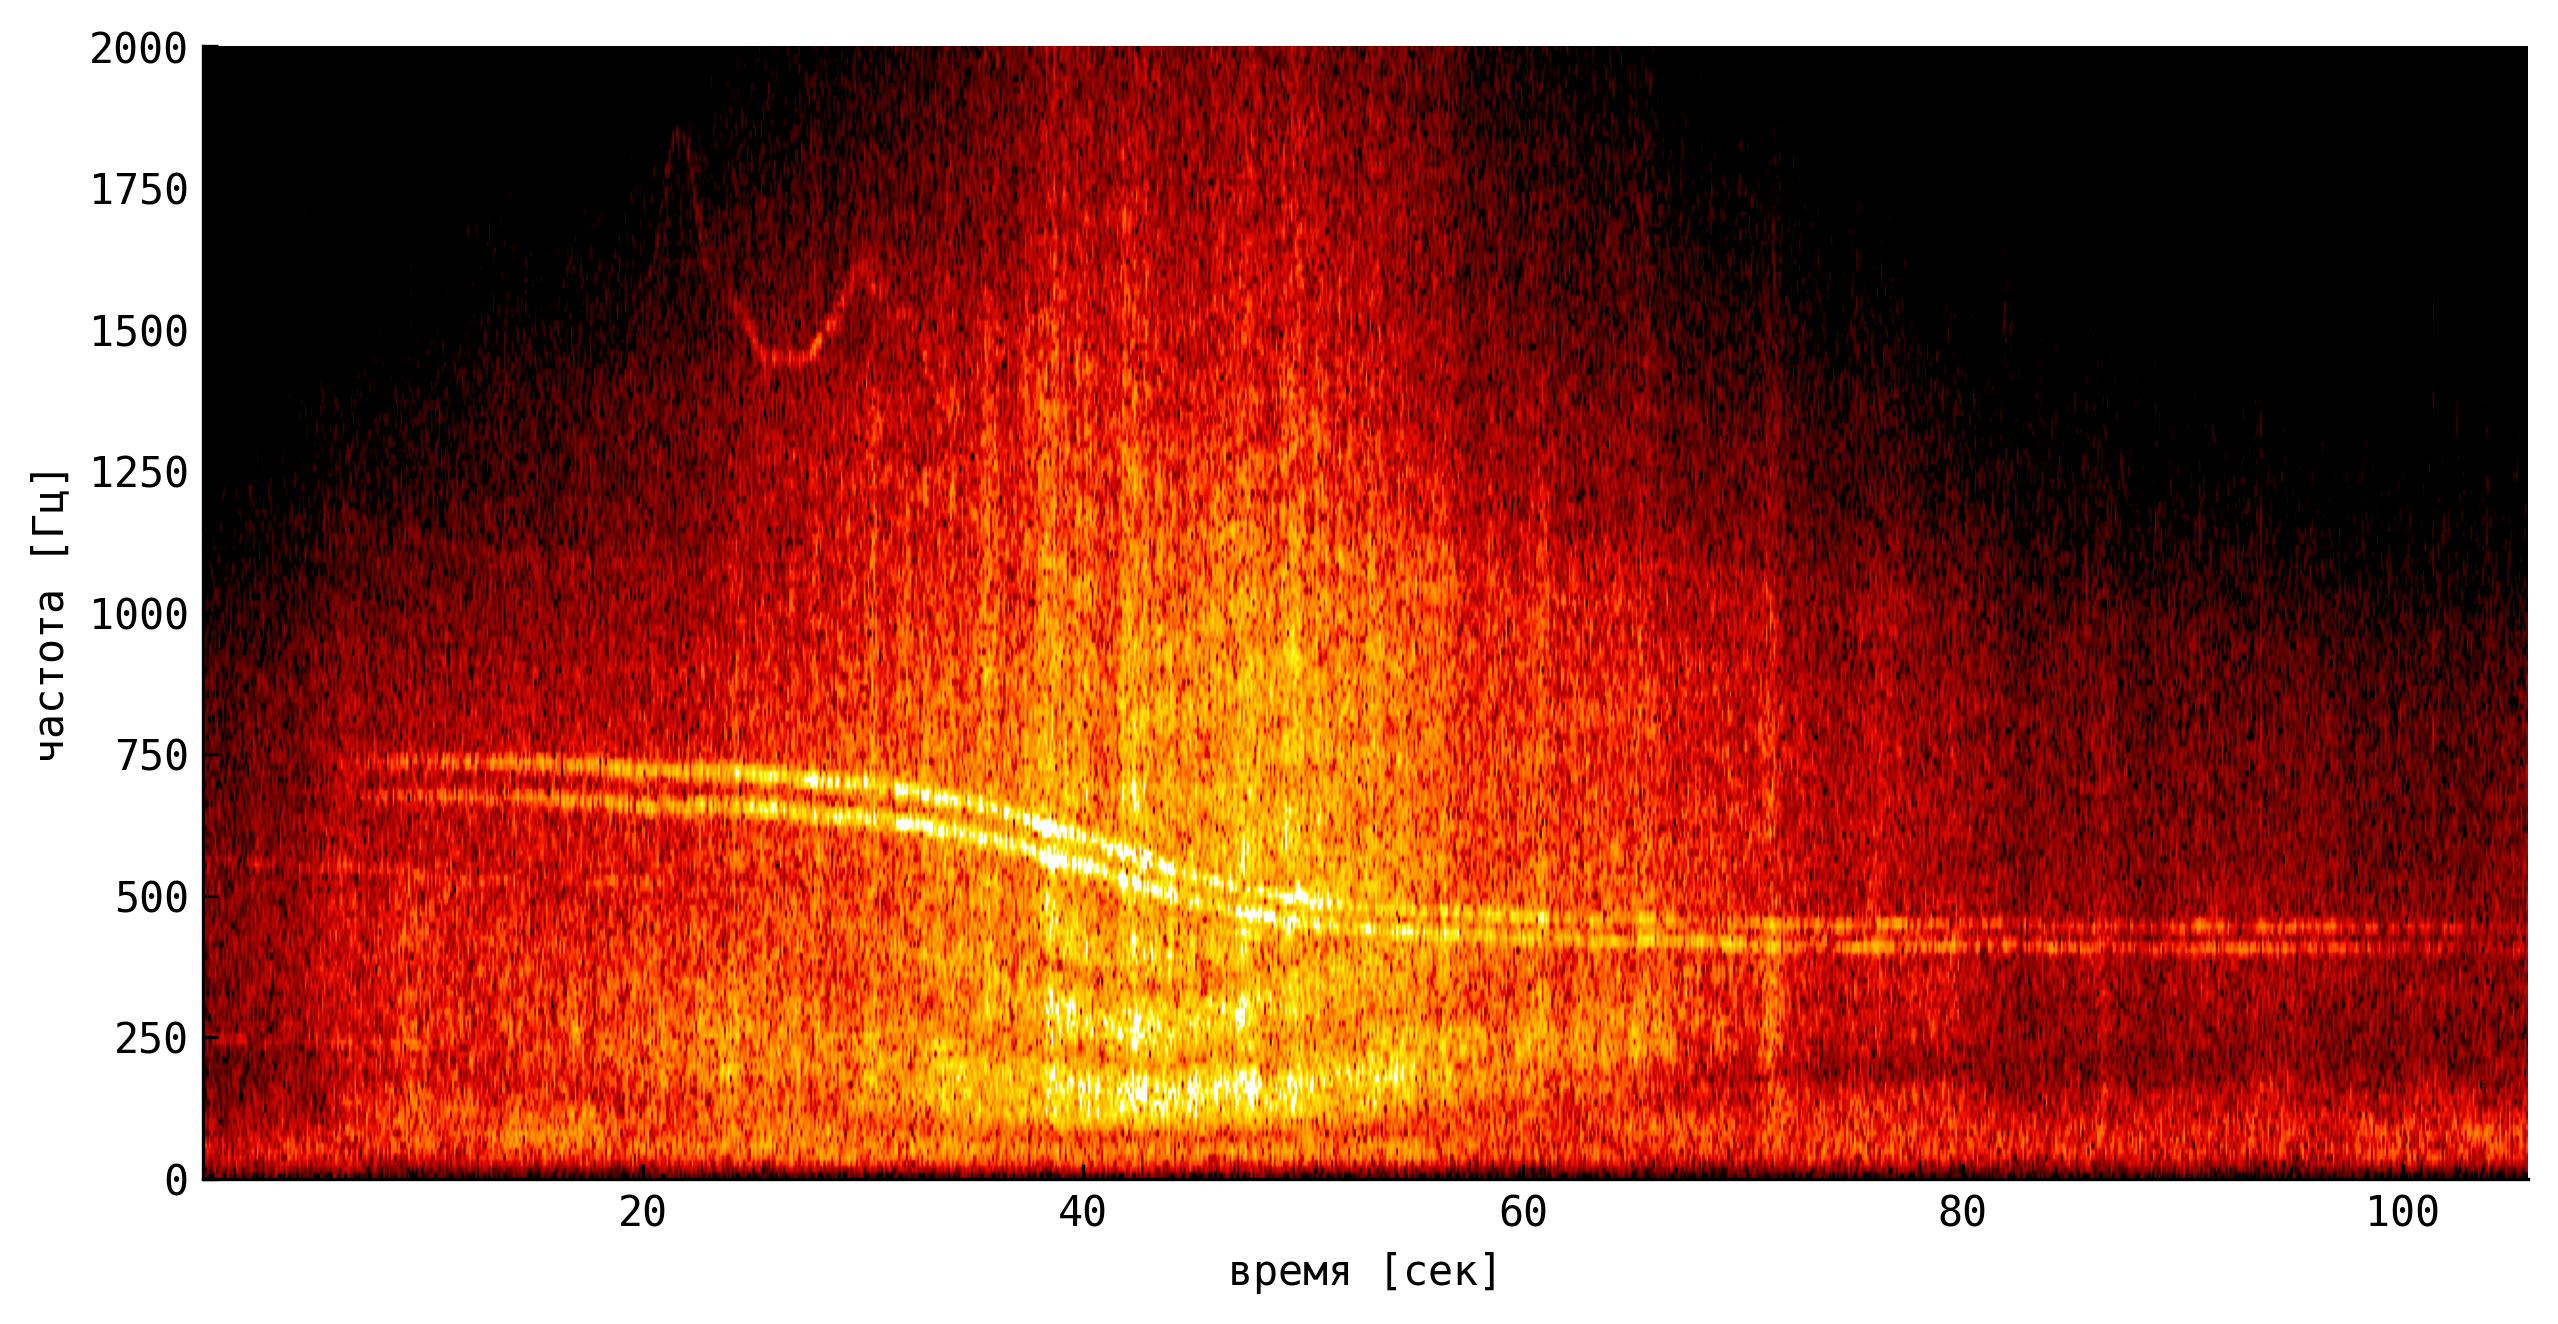

In [153]:
#@title { vertical-output: true }
fig = plt.figure(figsize=(10, 5), dpi=300)
ax = fig.subplots()
im = ax.specgram(
    samples, 
    Fs=samplerate,
    cmap='fire', 
    **props
);
ax.set(
    **lims,
    #    yscale='log', 
    ylabel='частота [Гц]', 
    xlabel='время [сек]'
);
# addCbar(fig, ax, im[-1]);
ax.grid(False)
plt.savefig('airliner1.png')